In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
from math import comb
from odeintw import odeintw
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="darkgrid", context="talk")

# Exercises part I: SIS dynamics

### SIS dynamics with spontaneous infections

1) First, construct the master equation.

What are the possible states?

$n \in \{0, 1, 2, \ldots, N\}$

What are the transitions?

$n \to n+1 \text{ (infection, contact or spontaneous)}, \quad n \to n-1 \text{ (recovery, only if } n > 0)$

At what rates do these transitions occur??

Infection by contact: $\beta(N-n)n$

Spontanious infection: $\epsilon(N-n)$

Recovery: $\alpha n$

From this we can write the master equation as follows:

$\frac{dP_n}{dt} = \bigl[\beta(n-1)(N-n+1) + \epsilon(N-n+1)\bigr]P_{n-1} + \alpha(n+1)P_{n+1} - \bigl[\beta n(N-n) + \epsilon(N-n) + \alpha n\bigr]P_n$

2) Integrate the master equation over time to look at the behavior of the system for different values of the parameters. What happens if $N$ 
goes to one? What happens if $\beta$ or $\epsilon$ go to zero?

1.0000000000000027
0.9999999999999998
1.0000000000000002
1.0


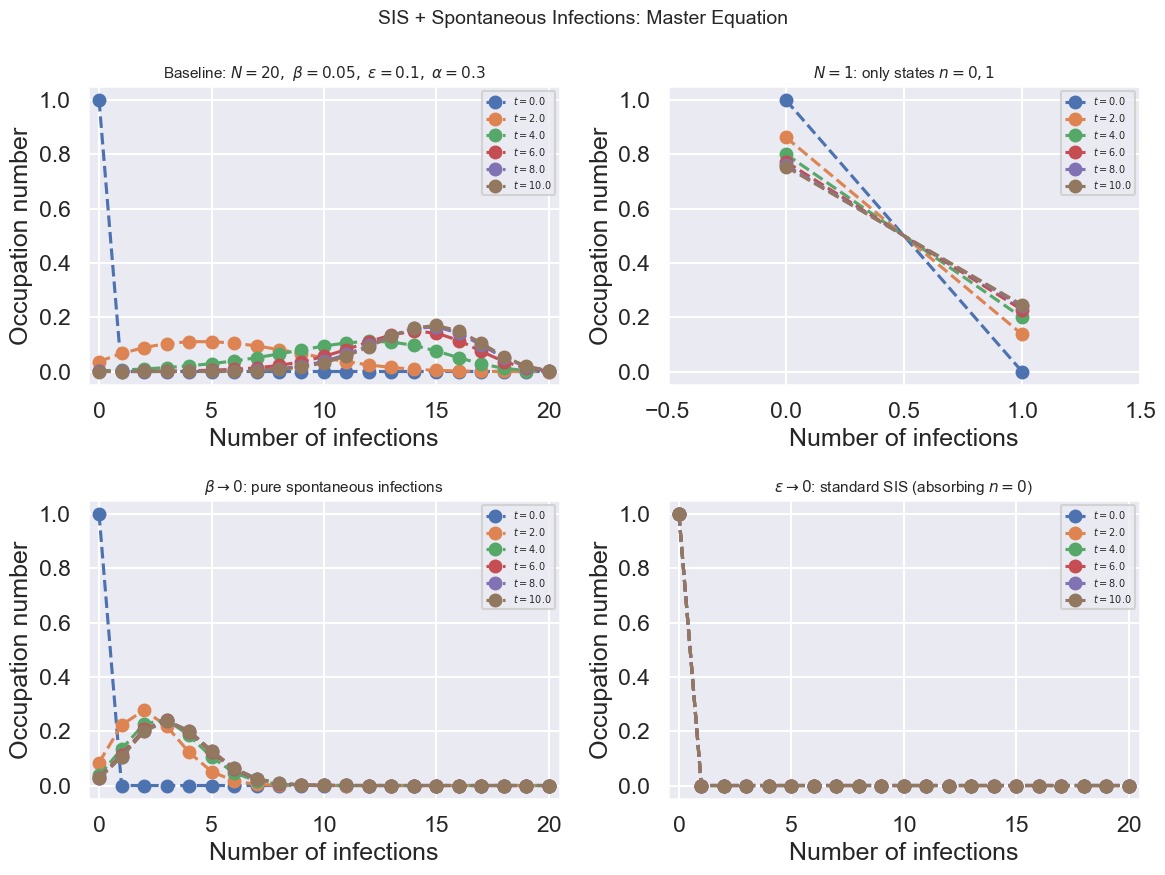

In [96]:
def sis_spontaneous(x, t, N, beta, epsilon, alpha):
    """
    Master equation for SIS dynamics with spontaneous infections.
    
        * x       : probability distribution over states (len = N+1)
        * t       : time (scalar)
        * N       : population size
        * beta    : contact infection rate
        * epsilon : spontaneous infection rate
        * alpha   : recovery rate
    """
    dx = 0 * x

    for n in range(N + 1):
        if n == 0:  # left boundary: no recovery possible, no P_{-1}
            rate_up = N * epsilon                        # ε(N-0)
            dx[n] = -rate_up * x[0] + alpha * 1 * x[1]

        elif n == N:  # right boundary: no infection possible, no P_{N+1}
            rate_down = alpha * N                        # all N infected can recover
            inflow    = beta * (N-1) * 1 + epsilon * 1  # β(n-1)(N-n+1) + ε(N-n+1) at n=N
            dx[n] = -rate_down * x[N] + inflow * x[N-1]

        else:  # interior: all four arrows present
            rate_up   = (N - n) * (beta * n + epsilon)                    # n -> n+1
            rate_down = alpha * n                                          # n -> n-1
            inflow    = beta * (n-1) * (N-n+1) + epsilon * (N-n+1)       # from n-1
            dx[n] = (- (rate_up + rate_down) * x[n]
                     + alpha * (n + 1) * x[n + 1]
                     + inflow * x[n - 1])

    return dx


# ── Shared settings ──────────────────────────────────────────────────────────
t_vec = np.linspace(0, 10, 1000)

def run_and_plot(ax, N, beta, epsilon, alpha, title):
    """Integrate and plot P_n(t) for a given parameter set."""
    x_0 = np.zeros(N + 1)
    x_0[0] = 1.0  # start fully susceptible

    rhs = lambda x, t: sis_spontaneous(x, t, N, beta, epsilon, alpha)
    x_path = odeint(rhs, x_0, t_vec)
    print(np.sum(x_path[-1]))

    # Plot a few time snapshots
    snapshot_indices = np.linspace(0, len(t_vec) - 1, 6, dtype=int)
    for i in snapshot_indices:
        ax.plot(range(N + 1), x_path[i], marker='o', ls='--',
                label=fr"$t={t_vec[i]:.1f}$")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Number of infections')
    ax.set_ylabel('Occupation number')
    ax.legend(fontsize=7)
    ax.set_xlim(-0.5, N + 0.5)


# ── Parameter scenarios ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('SIS + Spontaneous Infections: Master Equation', fontsize=14)

# Baseline
run_and_plot(axes[0, 0], N=20, beta=0.05, epsilon=0.1, alpha=0.3,
             title=r'Baseline: $N=20,\ \beta=0.05,\ \epsilon=0.1,\ \alpha=0.3$')

# N -> 1 (trivial system: only states 0 and 1)
run_and_plot(axes[0, 1], N=1,  beta=0.05, epsilon=0.1, alpha=0.3,
             title=r'$N = 1$: only states $n=0,1$')

# beta -> 0 (only spontaneous infections drive spread)
run_and_plot(axes[1, 0], N=20, beta=0.0,  epsilon=0.1, alpha=0.5,
             title=r'$\beta \to 0$: pure spontaneous infections')

# epsilon -> 0 (standard SIS — n=0 becomes absorbing again)
run_and_plot(axes[1, 1], N=20, beta=0.05, epsilon=0.0, alpha=0.3,
             title=r'$\epsilon \to 0$: standard SIS (absorbing $n=0$)')

plt.tight_layout()
plt.savefig('sis_spontaneous.png', dpi=150)
plt.show()

3) Solve the steady-state of the master equation analytically using any of the methods studied in this tutorial.

#### Setup

The master equation for the SIS model with spontaneous infections is:
$$\frac{dP_n}{dt} = \bigl[\beta(n-1)(N-n+1) + \epsilon(N-n+1)\bigr]P_{n-1} + \alpha(n+1)P_{n+1} - \bigl[\beta n(N-n) + \epsilon(N-n) + \alpha n\bigr]P_n$$

At steady state, detailed balance gives us a ratio between adjacent states:

$$
\frac{P_n}{P_{n-1}} = \frac{\beta(n-1)(N-n+1) + \varepsilon(N-n+1)}{\alpha n}
$$

Let $P_0$ be its own thing to start the series. One can then write the next few terms as:

\begin{align*}
n=1: \quad P_1 &= \frac{N\varepsilon}{\alpha \cdot 1} \cdot P_0
    = \frac{N\varepsilon}{\alpha} P_0 \\[6pt]
n=2: \quad P_2 &= \frac{(N-1)(\beta + \varepsilon)}{\alpha \cdot 2} \cdot P_1
    = \frac{(N-1)(\beta+\varepsilon)}{2\alpha}
      \cdot \frac{N\varepsilon}{\alpha} P_0
    = \frac{N(N-1)\,\varepsilon(\beta+\varepsilon)}{2!\,\alpha^2} P_0 \\[6pt]
n=3: \quad P_3 &= \frac{(N-2)(2\beta+\varepsilon)}{\alpha \cdot 3} \cdot P_2
    = \frac{(N-2)(2\beta+\varepsilon)}{3\alpha}
      \cdot \frac{N(N-1)\,\varepsilon(\beta+\varepsilon)}{2!\,\alpha^2} P_0
    = \frac{N(N-1)(N-2)\,\varepsilon(\beta+\varepsilon)(2\beta+\varepsilon)}{3!\,\alpha^3} P_0
\end{align*}

Three patterns emerge:

- **Falling factorial** in the numerator: $N(N-1)\cdots(N-n+1) = N!/(N-n)!$
- **Running product** of infection pressures: $\prod_{k=0}^{n-1}(k\beta+\varepsilon)$
- **Denominator**: $n!\,\alpha^n$

The falling factorial divided by $n!$ is exactly $\binom{N}{n}$, so the general term is:

$$\boxed{P_n = \binom{N}{n} \cdot \frac{1}{\alpha^n}
  \cdot \prod_{k=0}^{n-1}(k\beta+\varepsilon) \cdot P_0}$$

#### Normalization

And all that is left is to solve for $P_0$. What else can we use? Our normalization condition: $\sum_n P_n = 1$. We therefore write

$$\frac{1}{P_0} = \sum_{n=0}^{N} \binom{N}{n} \cdot \frac{1}{\alpha^n}
  \cdot \prod_{k=0}^{n-1}(k\beta+\varepsilon)$$

The $n=0$ term in the sum is $1$ (empty product equals $1$, $\binom{N}{0}=1$),
so the bracket is always $\geq 1$ and $P_0 \leq 1$ as required.
Unlike the birth-death case --- where the analogous sum collapses to $e^{\mu/\nu}$ --- this
sum has no closed form and must be evaluated numerically for given $N, \alpha, \beta, \varepsilon$.

3) Continued... Does the solution capture the intuition you built by integrating the system for different values of $\epsilon$?

Below I compare the coded and analytical solutions in the form of a table. The 2 solutions are indistinguishable.

In [115]:
def analytical_steady_state(N, beta, epsilon, alpha):
    P_unnorm = np.zeros(N + 1)
    for n in range(N + 1):
        # product_{k=0}^{n-1} (k*beta + epsilon); empty product = 1 when n=0
        running_product = np.prod([k * beta + epsilon for k in range(n)]) if n > 0 else 1.0
        P_unnorm[n] = comb(N, n) * running_product / (alpha ** n)
    P_unnorm /= P_unnorm.sum()
    return P_unnorm
 
 
N, beta, epsilon, alpha = 20, 0.05, 0.1, 0.3
 
t_vec = np.linspace(0, 200, 500)
x_0 = np.zeros(N + 1); x_0[0] = 1.0
rhs = lambda x, t: sis_spontaneous(x, t, N, beta, epsilon, alpha)
x_path = odeint(rhs, x_0, t_vec)
P_numerical = x_path[-1]  # last time step ≈ steady state
 
# math.comb() method returns the number of ways picking k unordered outcomes from n possibilities, without repetition, also known as combinations
# https://www.w3schools.com/python/ref_math_comb.asp
P_analytical = analytical_steady_state(N, beta, epsilon, alpha)
 
print(f"{'n':>4} | {'Analytical':>12} | {'Numerical':>12} | {'Difference':>14}")
print("-" * 50)
for n in range(N + 1):
    print(f"{n:>4} | {P_analytical[n]:>12.8f} | {P_numerical[n]:>12.8f} | {P_analytical[n]-P_numerical[n]:>+14.2e}")
 

   n |   Analytical |    Numerical |     Difference
--------------------------------------------------
   0 |   0.00000025 |   0.00000025 |      +3.82e-19
   1 |   0.00000166 |   0.00000166 |      +1.56e-18
   2 |   0.00000786 |   0.00000786 |      +4.85e-18
   3 |   0.00003146 |   0.00003146 |      +1.33e-17
   4 |   0.00011141 |   0.00011141 |      +3.32e-17
   5 |   0.00035650 |   0.00035650 |      +7.56e-17
   6 |   0.00103980 |   0.00103980 |      +1.55e-16
   7 |   0.00277279 |   0.00277279 |      +2.84e-16
   8 |   0.00675869 |   0.00675869 |      +4.46e-16
   9 |   0.01501931 |   0.01501931 |      +5.45e-16
  10 |   0.03028893 |   0.03028893 |      +3.78e-16
  11 |   0.05507079 |   0.05507079 |      -4.23e-16
  12 |   0.08949003 |   0.08949003 |      -2.22e-15
  13 |   0.12849851 |   0.12849851 |      -5.08e-15
  14 |   0.16062314 |   0.16062314 |      -8.38e-15
  15 |   0.17133134 |   0.17133134 |      -1.08e-14
  16 |   0.15169963 |   0.15169963 |      -1.11e-14
  17 |   0.10

4) Can you derive the standard SIS equation using the method of moments? Do you have to make any approximation to recover the standard solution?


#### Setup

The master equation for the SIS model with spontaneous infections is:

$$\frac{dP_n}{dt} = \bigl[\beta(n-1)(N-n+1) + \varepsilon(N-n+1)\bigr]P_{n-1} - \bigl[\beta n(N-n) + \varepsilon(N-n) + \alpha n\bigr]P_n + \alpha(n+1)P_{n+1}$$

The Method of Moments (MoM) move: multiply both sides by $n$ and sum over all $n$:

$$\frac{d\langle n\rangle}{dt} = \sum_n n\frac{dP_n}{dt}$$

This produces three sums — one for each term in the master equation.

#### Sum A — Gain from left (inflow from state $n-1$)

$$A = \sum_n n\cdot\bigl[\beta(n-1)(N-n+1) + \varepsilon(N-n+1)\bigr]P_{n-1}$$

Re-index with $m = n-1$ (so $n = m+1$):

$$A = \sum_m (m+1)\bigl[\beta m(N-m) + \varepsilon(N-m)\bigr]P_m$$

#### Sum B — Loss term (outflow from state $n$)

$$B = -\sum_n n\left[(N-n)(\beta n+\varepsilon) + \alpha n\right]P_n$$

Distribute the $n$ and the outer negative through the bracket:

$$B = -\sum_n n(N-n)(\beta n+\varepsilon)P_n - \alpha\sum_n n^2 P_n$$

Recognize the second sum as the second moment:

$$B = -\sum_n n(N-n)(\beta n+\varepsilon)P_n - \alpha\langle n^2\rangle$$

#### Sum C — Gain from right (inflow from state $n+1$)

$$C = \sum_n n\cdot\alpha(n+1)P_{n+1}$$

Re-index with $m = n+1$ (so $n = m-1$):

$$C = \alpha\sum_m (m-1)m\, P_m$$

Expand $(m-1)m = m^2 - m$ and split:

$$C = \alpha\sum_m m^2 P_m - \alpha\sum_m m\, P_m = \alpha\langle n^2\rangle - \alpha\langle n\rangle$$

#### Combining A + B + C

Notice the $\alpha\langle n^2\rangle$ terms cancel:

$$-\alpha\langle n^2\rangle \quad\text{(from B)} \quad+\quad \alpha\langle n^2\rangle \quad\text{(from C)} \quad= 0$$

Noting that $\beta m(N-m) + \varepsilon(N-m) = (N-m)(\beta m+\varepsilon)$, we can write:

$$\frac{d\langle n\rangle}{dt} = \sum_m(m+1)(N-m)(\beta m+\varepsilon)P_m - \sum_m m(N-m)(\beta m+\varepsilon)P_m - \alpha\langle n\rangle$$

The two sums differ only in their leading factor — $(m+1)$ vs $m$ — so they combine:

$$\sum_m\left[(m+1) - m\right](N-m)(\beta m+\varepsilon)P_m = \sum_m(N-m)(\beta m+\varepsilon)P_m$$

#### Expanding the remaining sum

$$\sum_m(N-m)(\beta m+\varepsilon)P_m = \sum_m\left(\beta Nm - \beta m^2 + N\varepsilon - \varepsilon m\right)P_m$$

$$= \beta N\langle n\rangle - \beta\langle n^2\rangle + N\varepsilon - \varepsilon\langle n\rangle$$

So the full **exact** equation (no approximation yet) is:

$$\boxed{\frac{d\langle n\rangle}{dt} = \beta N\langle n\rangle - \beta\langle n^2\rangle + N\varepsilon - \varepsilon\langle n\rangle - \alpha\langle n\rangle}$$

This depends on $\langle n^2\rangle$, which we do not yet have an equation for — this is the closure problem.

Is only true for a delta distribution... -LHD  (Thank you for this feedback!)

#### Moment Closure

The exact equation depends on $\langle n^2 \rangle$, which requires its own evolution equation — and that equation will depend on $\langle n^3 \rangle$, and so on. This is the **moment hierarchy problem**: the system never closes on its own.

To truncate it, we apply the **mean-field closure**:

$$\langle n^2\rangle \approx \langle n\rangle^2$$

This is equivalent to assuming $\text{Var}(n) = \langle n^2\rangle - \langle n\rangle^2 = 0$, which holds exactly only for a **Dirac delta distribution** — a distribution with all its probability mass concentrated at a single point. In other words, the closure replaces the true stochastic distribution with a deterministic point mass at $\langle n \rangle$, eliminating fluctuations entirely.

This approximation is reasonable (though never exact) in the limit of large, well-mixed populations, where the relative variance $\text{Var}(n)/\langle n \rangle^2 \ll 1$. In acknowledging LHD's comment "this is only true for a delta distribution," we are not merely assuming the distribution is narrow — we are asserting it is a delta function, and the quality of the approximation degrades as fluctuations grow.

Under this closure:

$$\frac{d\langle n\rangle}{dt} = \beta N\langle n\rangle - \beta\langle n\rangle^2 + N\varepsilon - \varepsilon\langle n\rangle - \alpha\langle n\rangle$$

#### Factoring

**Factor the $\beta$ terms:

$$\beta N\langle n\rangle - \beta\langle n\rangle^2 = \beta\langle n\rangle(N - \langle n\rangle)$$

**Factor the $\varepsilon$ terms:

$$N\varepsilon - \varepsilon\langle n\rangle = \varepsilon(N - \langle n\rangle)$$

**The full expression is now:

$$\beta\langle n\rangle(N - \langle n\rangle) + \varepsilon(N - \langle n\rangle) - \alpha\langle n\rangle$$

**Factor out the common $(N - \langle n\rangle)$:

$$\frac{d\langle n\rangle}{dt} = (N - \langle n\rangle)(\beta\langle n\rangle + \varepsilon) - \alpha\langle n\rangle$$

#### Recovering the Standard SIS Equation

Setting $I = \langle n\rangle$ and $S = N - \langle n\rangle$:

$$\boxed{\frac{dI}{dt} = S(\beta I + \varepsilon) - \alpha I}$$

When $\varepsilon = 0$, the spontaneous infection term vanishes and we recover the standard SIS equation:

$$\frac{dI}{dt} = \beta S I - \alpha I$$

or equivalently in terms of $S$ alone (using $I = N - S$):

$$\dot{S} = \alpha(N - S) - \beta S(N - S)$$

# Exercises part II: Enzymes

### Enzymes and chemical reactions

1) First, construct a master equation model.

What are the possible states?

$s \in \{0, 1, 2, \ldots, S(0)\}$

Let $C$ be the maximum number of complexes that can exist, which will be the min of $E(0)$ and $S(0)$.

$c \in \{0, 1, 2, \ldots, C\}$

What are the transitions?

$(s, c) \to (s - 1, c + 1) \text{ (binding if } s > 0 \text{ and } c < E(0)), \quad (s, c) \to (, c - 1) \text{ (reaction if } c > 0)$

At what rates do these transitions occur??

Binding: $k \cdot s \cdot (E(0) - c)$

Reaction: $k_{r} \cdot c$

From this we can write the master equation as follows:

$
\frac{d}{dt}P(s,c) = k(s+1)(E(0)-c+1)\,P(s+1,\,c-1) + k_\text{r}(c+1)\,P(s,\,c+1) - \bigl[k\cdot s(E(0)-c) + k_\text{r}\cdot c\bigr]P(s,c)
$

2) Integrate your master equation over time to look at the behavior of the system for different values of $E(0)$.

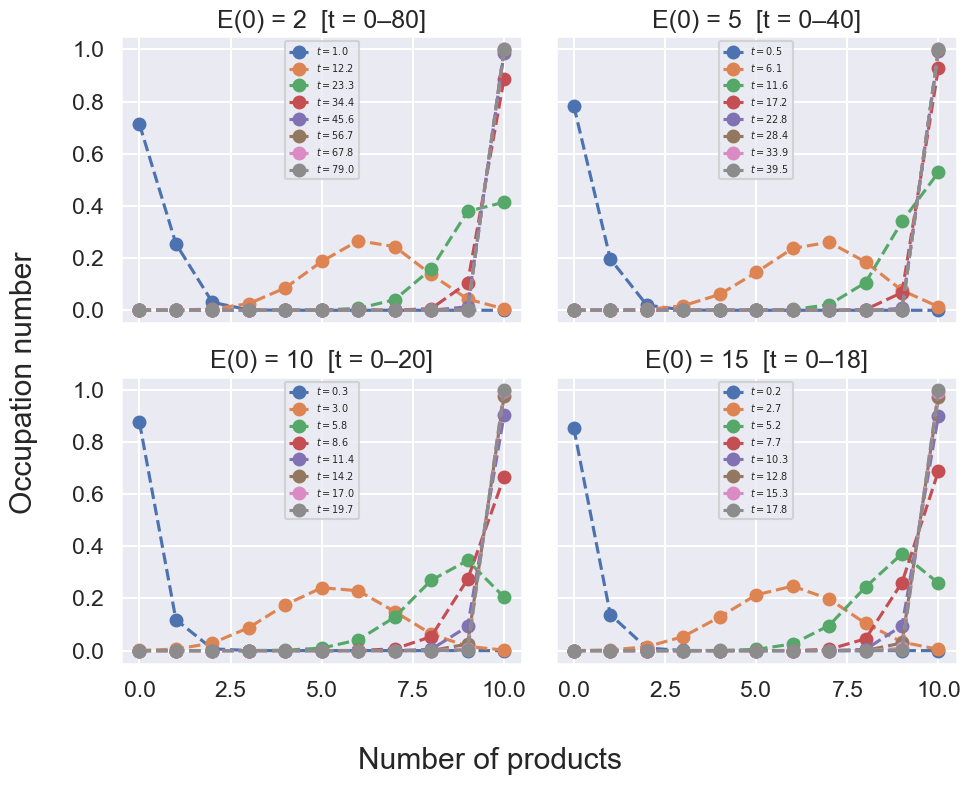

In [92]:
def enzyme_me(x, t, S0, E0, k, k_r):
    """
    Time derivative of the occupation numbers for enzyme-substrate kinetics.

        * x     : probability distribution over states P[s, c]
        * t     : time (scalar)
        * S0    : initial substrate count S(0)
        * E0    : enzyme count E(0)
        * k     : binding rate
        * k_r   : reaction rate

    Transitions:
        (s, c) -> (s-1, c+1)  binding,  rate k * s * (E0 - c)
        (s, c) -> (s,   c-1)  reaction, rate k_r * c
    """
    dx = 0 * x

    for s, c in np.ndindex(x.shape):

        if s + c > S0:          # outside triangular state space
            continue

        # --- outflow ---
        dx[s, c] -= k * s * (E0 - c) * x[s, c]        # binding out
        dx[s, c] -= k_r * c * x[s, c]                # reaction out

        # --- inflow from binding: (s+1, c-1) -> (s, c) ---
        if c >= 1 and (s + 1) + (c - 1) <= S0:
            dx[s, c] += k * (s + 1) * (E0 - c + 1) * x[s + 1, c - 1]

        # --- inflow from reaction: (s, c+1) -> (s, c) ---
        if c + 1 <= E0 and s + (c + 1) <= S0:
            dx[s, c] += k_r * (c + 1) * x[s, c + 1]

    return dx

S0        = 10
k         = 0.1
k_r       = 0.5
E0_values = [2, 5, 10, 15]
t_lengths = {2: 80, 5: 40, 10: 20, 15: 18}
t_steps   = 80

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True, sharex=True)

for ax, E0 in zip(axes.flat, E0_values):
    C     = min(S0, E0)
    t_vec = np.linspace(0, t_lengths[E0], t_steps)

    x_0 = np.zeros((S0 + 1, C + 1))
    x_0[S0, 0] = 1.0

    G      = lambda x, t: enzyme_me(x, t, S0, E0, k, k_r)
    x_path = odeintw(G, x_0, t_vec)

    for t in np.arange(1, t_steps - 1, t_steps // 7):
        p_dist = np.zeros(S0 + 1)
        for s in range(S0 + 1):
            for c in range(C + 1):
                p = S0 - s - c
                if 0 <= p <= S0:
                    p_dist[p] += x_path[t, s, c]

        ax.plot(range(S0 + 1), p_dist,
                marker='o', ls='--', label=fr'$t={t_vec[t]:.1f}$')

    ax.set_title(f'E(0) = {E0}  [t = 0–{t_lengths[E0]}]')
    ax.legend(fontsize=7)

fig.supxlabel('Number of products')
fig.supylabel('Occupation number')
plt.tight_layout()
plt.show()

3) Write a mean-field version of the same dynamics.

Consider a compartmental model with four compartments: $S$ (substrate), $E$ (free enzyme),
$C$ (complex), and $P$ (product), connected by two transitions.

Substrate and free enzyme bind at rate $k \cdot S \cdot E$, flowing jointly into the complex
compartment $C$. From $C$, a reaction occurs at rate $k_r \cdot C$, releasing the product
into $P$ and returning the enzyme to the free enzyme compartment $E$.

This gives us four variables, but the system has two conserved quantities:
\begin{align*}
    S + C + P &= S(0) \qquad \text{(every substrate molecule is in exactly one compartment)}\\
    E + C &= E(0) \qquad \text{(every enzyme molecule is in exactly one compartment)}
\end{align*}

These two constraints remove two degrees of freedom, leaving only two independent variables.
Choosing $S$ and $C$ as our free variables and substituting $E = E(0) - C$, the full
system collapses to:
\begin{align*}
    \dot{S} &= -k\, S\,(E(0) - C) \\
    \dot{C} &= k\, S\,(E(0) - C) - k_r\, C
\end{align*}

with $P$ and $E$ fully determined at any time from the conserved quantities. We never
need to write ODEs for them explicitly --- they carry no additional information beyond
what $S$ and $C$ already tell us.

Can the mean-field model predict the initial production rate $\dot{P}(0)$?

We can caclulate $P$ from conservation: $P = S(0) - S - C$

We can then differentiate with respect to $t$. This gives us $\dot{P} = - \dot{S} - \dot{C}$

Now we make substitutions from mean-field: $\dot{P} = -\dot{S} - \dot{C} = -(-k S(E(0) - C)) - (k S(E(0) - C) - k_r C) = k_r C$

$
\dot{P} = k_r C
$

At $t=0$, we have 0 complex, so $\dot{P} = 0$

Can you analytically solve this initial production rate?

Again, we differentiate $\dot{P} = k_r C$ with respect to time $t$, noting $k_r$ is a constant: $\ddot{P} = k_r \dot{C}$

Substituting the mean-field ODE for $\dot{C}$: $\ddot{P} = k_r \left[ k S(E(0) - C) - k_r C \right]$

Evaluating at $t = 0$, where $C(0) = 0$: $\ddot{P}(0) = k_r \left[ k \cdot S(0) \cdot E(0) - k_r \cdot 0 \right]$

$\ddot{P}(0) = k \cdot k_r \cdot S(0) \cdot E(0)$

Make substitutions from mean-field: $\ddot{P} = k S(E(0) - C) - k_r C$

We can do a quick check to make sure our calculations are correct!


In [93]:
def mean_field(y, t, S0, E0, k, k_r):
    S, C = y
    dS = -k * S * (E0 - C)
    dC =  k * S * (E0 - C) - k_r * C
    return [dS, dC]

k     = 0.1
k_r   = 0.5
t_vec = np.linspace(0, 10, 5000)
dt    = t_vec[1] - t_vec[0]

S0_values = [2, 5, 10, 20]
E0_values = [2, 5, 10, 15]

for i, S0 in enumerate(S0_values):
    for j, E0 in enumerate(E0_values):
        # --- analytic prediction ---
        analytic = k * k_r * S0 * E0

        # --- numerical estimate ---
        sol = odeint(mean_field, [S0, 0.0], t_vec, args=(S0, E0, k, k_r))
        C   = sol[:, 1]
        # finite difference on k_r * C to get ddot{P}
        Pdot    = k_r * C
        Pddot_0 = (Pdot[1] - Pdot[0]) / dt
        print(f"analytic: {analytic:.4f}, numerical: {Pddot_0:.4f}  (S0={S0}, E0={E0})")

analytic: 0.2000, numerical: 0.1998  (S0=2, E0=2)
analytic: 0.5000, numerical: 0.4994  (S0=2, E0=5)
analytic: 1.0000, numerical: 0.9983  (S0=2, E0=10)
analytic: 1.5000, numerical: 1.4967  (S0=2, E0=15)
analytic: 0.5000, numerical: 0.4994  (S0=5, E0=2)
analytic: 1.2500, numerical: 1.2481  (S0=5, E0=5)
analytic: 2.5000, numerical: 2.4950  (S0=5, E0=10)
analytic: 3.7500, numerical: 3.7406  (S0=5, E0=15)
analytic: 1.0000, numerical: 0.9983  (S0=10, E0=2)
analytic: 2.5000, numerical: 2.4950  (S0=10, E0=5)
analytic: 5.0000, numerical: 4.9875  (S0=10, E0=10)
analytic: 7.5000, numerical: 7.4776  (S0=10, E0=15)
analytic: 2.0000, numerical: 1.9946  (S0=20, E0=2)
analytic: 5.0000, numerical: 4.9850  (S0=20, E0=5)
analytic: 10.0000, numerical: 9.9651  (S0=20, E0=10)
analytic: 15.0000, numerical: 14.9402  (S0=20, E0=15)


4) Can the mean-field model predict the expected half-life of the substrate at different level of $S(0)$?

As we see in the plots below, as $S(0)$ increases so does the half-life of the substrate. The expectation here 
is that $E(0)$ does not increase. Essentially, the increasing substrate overwhelms the free enzymes, which
increases the half-life. 

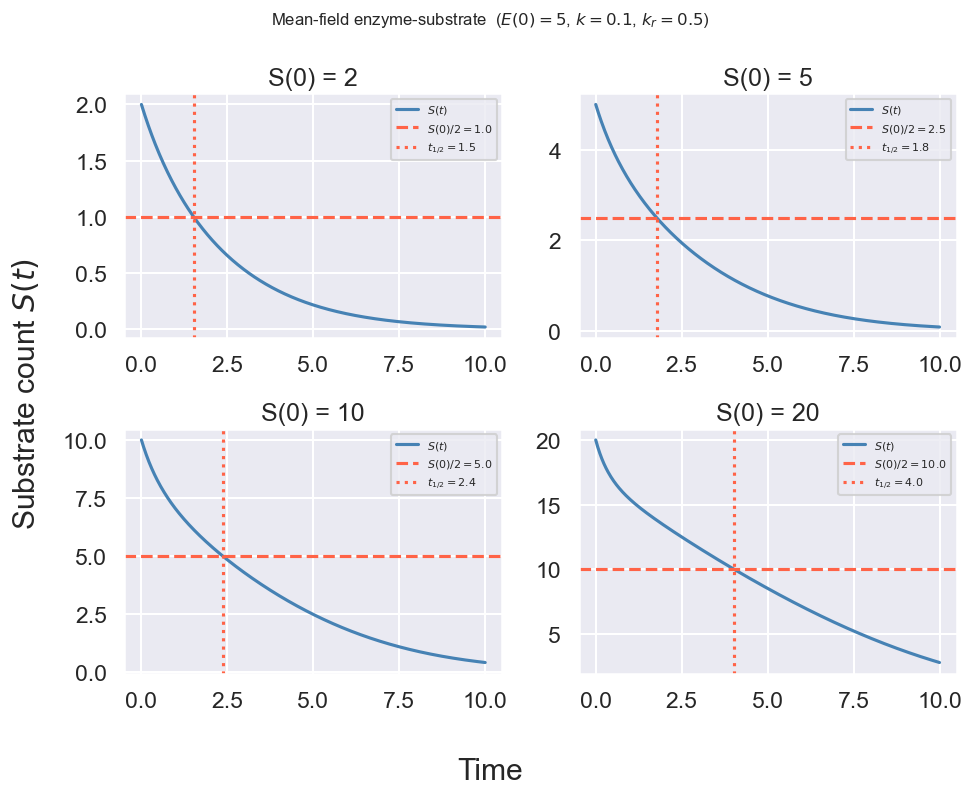

In [94]:
def mean_field(y, t, S0, E0, k, k_r):
    """
        * y     : [S, C] mean substrate and complex counts
        * t     : time (scalar)
        * S0    : initial substrate count S(0)
        * E0    : enzyme count E(0)
        * k     : binding rate
        * k_r   : reaction rate

    Transitions:
        S -> C   binding,  rate k * S * (E0 - C)
        C -> P   reaction, rate k_r * C
    """
    S, C = y
    dS = -k * S * (E0 - C)
    dC =  k * S * (E0 - C) - k_r * C
    return [dS, dC]

E0        = 5
k         = 0.1
k_r       = 0.5
S0_values = [2, 5, 10, 20]
t_max   = 10
t_steps = 500

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False, sharex=False)

for ax, S0 in zip(axes.flat, S0_values):
    t_vec = np.linspace(0, t_max, t_steps)

    y0  = [S0, 0.0]
    sol = odeint(mean_field, y0, t_vec, args=(S0, E0, k, k_r))
    S   = sol[:, 0]

    # find half-life
    idx = np.where(S <= S0 / 2)[0]
    t_half = t_vec[idx[0]] if len(idx) > 0 else np.nan

    ax.plot(t_vec, S, color='steelblue', label='$S(t)$')
    ax.axhline(S0 / 2, color='tomato',   linestyle='--', label=f'$S(0)/2 = {S0/2}$')
    if not np.isnan(t_half):
        ax.axvline(t_half, color='tomato', linestyle=':',
                   label=fr'$t_{{1/2}} = {t_half:.1f}$')

    ax.set_title(f'S(0) = {S0}')
    ax.legend(fontsize=8)

fig.supxlabel('Time')
fig.supylabel('Substrate count $S(t)$')
plt.suptitle(f'Mean-field enzyme-substrate  ($E(0) = {E0}$, $k = {k}$, $k_r = {k_r}$)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Exercises part III: Game theory
Payoff matrix:

$
A = \begin{pmatrix}
  0 & -1 &  1 \\
  1 &  0 & -1 \\
 -1 &  1 &  0 
\end{pmatrix}
$

1) First, construct a master equation model for the Moran process of the rock-paper-scissors game.

What are the states?

$\mathbf{n} = \begin{pmatrix} n_R \\ n_P \\ n_S \end{pmatrix}, \quad \mathbf{1}^T \mathbf{n} = N, \quad n_S = N - n_R - n_P$

What are the transitions?

Rather than enforce the fitness for each strategy, we let fitness emerge from random
pairwise encounters. At each step, two individuals are drawn uniformly at random without
replacement. They play a game, and the payoff matrix $A$ determines the outcome:

- $A_{ij} = +1$: individual $i$ wins and reproduces, $j$ loses (dies)
- $A_{ij} = 0$: tie nothing happens
- $A_{ij} = -1$: individual $i$ loses (dies) and $j$ reproduces

The probability of drawing individual of strategy $i$ first and strategy $j$ second is:

$$P(i, j) = \frac{n_i}{N} \cdot \frac{n_j}{N-1}$$

At what rates do these transitions occur?

For a transition where strategy $i$ reproduces and strategy $j$ dies ($T_{ij}$), we need
$A_{ij} = +1$. Since $A$ is antisymmetric, $A_{ji} = -1$ automatically — so both
orderings of the draw lead to the same outcome ($i$ reproduces, $j$ dies):

$$T_{ij} = \frac{n_i}{N} \cdot \frac{n_j}{N-1} + \frac{n_j}{N} \cdot \frac{n_i}{N-1} = \frac{2 n_i n_j}{N(N-1)}, \quad \text{when } A_{ij} = +1$$

Reading off the winning matchups from $A$ directly: $A_{PR} = 1$, $A_{RS} = 1$, $A_{SP} = 1$ — the only non-zero transition rates are:

$$T_{PR} = \frac{2 n_P n_R}{N(N-1)}, \quad T_{RS} = \frac{2 n_R n_S}{N(N-1)}, \quad T_{SP} = \frac{2 n_S n_P}{N(N-1)}$$

The losing transitions $T_{RP}$, $T_{SR}$, $T_{PS}$ are all zero. The loser never reproduces!

Construct the Master Equation

For each state $(n_R, n_P)$, there are only three ways probability can flow **in**
and three ways it can flow **out** one for each winning matchup in RPS:

**Gain terms** — three neighboring states that can transition *into* $(n_R, n_P)$:

| Transition | Arriving from |
|---|---|
| $T_{RS}$ (Rock beats Scissors) | $(n_R - 1,\ n_P)$ |
| $T_{PR}$ (Paper beats Rock) | $(n_R + 1,\ n_P - 1)$ |
| $T_{SP}$ (Scissors beats Paper) | $(n_R,\ n_P + 1)$ |

**Loss terms** — all three transitions that take you *away* from $(n_R, n_P)$, summed together.

Assembling everything:

$$\begin{aligned}
\frac{d}{dt}P(n_R, n_P, t)
&= T_{RS}(n_R{-}1,\, n_P)\, P(n_R{-}1,\, n_P) \\
&+ T_{PR}(n_R{+}1,\, n_P{-}1)\, P(n_R{+}1,\, n_P{-}1) \\
&+ T_{SP}(n_R,\, n_P{+}1)\, P(n_R,\, n_P{+}1) \\
&- \left[T_{RS} + T_{PR} + T_{SP}\right] P(n_R, n_P)
\end{aligned}$$

2) Second, write the replicator equations for the rock-paper-scissors game.

The TAME doc gives us a direct recipe for deriving the mean-field using the "replicator equation": $\dot{x}_{i}=x_{i}[f_{i}(x)-\phi(x)]$

Where $f_{i}(x)$ is the fitness of strategy $i$ given the distribution of strategies: $f_{i}(x)=\sum_{k=1}^{n}A_{i,k}x_{k}$

And $\phi(x)$ is the average fitness across all strategies: $\phi(x)=\sum_{j=1}^{n}x_{j}f_{j}(x)$

The game here is to calculate each and plug into the replicator equation. This approach gives validity to the recipe above in that
we see the same results fall out in the direct caclulations for steps 1 and 2 as we see above using the linear algebra approach
in caclulating fitness and mean fitness.

### Calculate $f_i$

Using $f_i(x) = \sum_k A_{ik} x_k$, we read off each row of $A$ and sum:

$$f_R = A_{RR}x_R + A_{RP}x_P + A_{RS}x_S = 0\cdot x_R + (-1)\cdot x_P + 1\cdot x_S = -x_P + x_S$$

$$f_P = A_{PR}x_R + A_{PP}x_P + A_{PS}x_S = 1\cdot x_R + 0\cdot x_P + (-1)\cdot x_S = x_R - x_S$$

$$f_S = A_{SR}x_R + A_{SP}x_P + A_{SS}x_S = (-1)\cdot x_R + 1\cdot x_P + 0\cdot x_S = -x_R + x_P$$

### Calculate $\phi(x)$

Using $\phi(x) = \sum_j x_j f_j(x)$, we weight each fitness by its frequency and sum:

$$\phi = x_R f_R + x_P f_P + x_S f_S$$

$$= x_R(-x_P + x_S) + x_P(x_R - x_S) + x_S(-x_R + x_P)$$

$$= -x_Rx_P + x_Rx_S + x_Px_R - x_Px_S - x_Sx_R + x_Sx_P$$

$$= \underbrace{(-x_Rx_P + x_Px_R)}_{=\,0} + \underbrace{(x_Rx_S - x_Sx_R)}_{=\,0} + \underbrace{(-x_Px_S + x_Sx_P)}_{=\,0} = 0$$

Every pair cancels because $A$ is antisymmetric — a direct consequence of RPS being zero-sum.

### Construct equations

With $\phi(x) = 0$, the replicator equation $\dot{x}_i = x_i[f_i(x) - \phi(x)]$ simplifies to $\dot{x}_i = x_i f_i(x)$. Substituting each fitness from Step 1:

$\dot{x}_R = x_R(-x_P + x_S)$

$\dot{x}_P = x_P(x_R - x_S)$

$\dot{x}_S = x_S(-x_R + x_P)$

3) Do the two approaches predict the same kind of behavior?

In the plots below, we can observe that there is no winner in the replicator. It is purely cyclical. The Moran process shows the same cyclic behavior early on, 
but finite-population noise (N = 30) causes stochastic drift that eventually pushes the trajectory to a boundary. This I believe is an instancee of fixation,
where one strategy (in this case, could be gene or whatever) takes over the entire population and the system reaches an absorbing state where all transition 
rates go to zero and nothing can change. Here, Scissors takes over around generation 10 and holds.

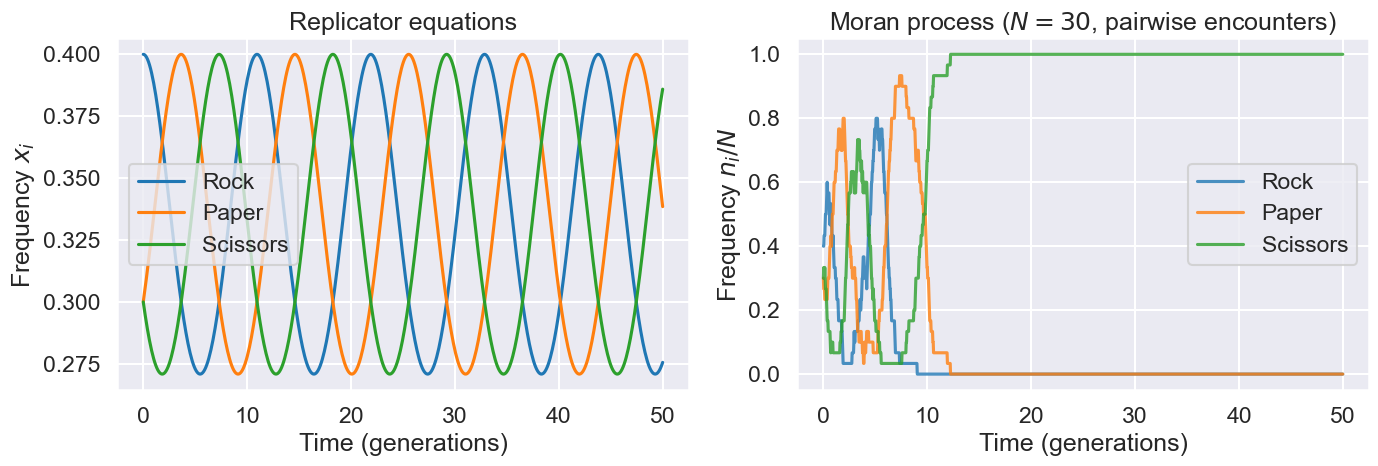

In [114]:
A = np.array([
    [ 0, -1,  1],
    [ 1,  0, -1],
    [-1,  1,  0]
])

def replicator(x, t):
    f = A @ x
    phi = x @ f
    return x * (f - phi)

def moran_step(n, N):
    strategies = [0, 1, 2]

    p_i = n / N
    i = np.random.choice(strategies, p=p_i)

    n_remaining = n.copy()
    n_remaining[i] -= 1
    p_j = n_remaining / (N - 1)
    j = np.random.choice(strategies, p=p_j)

    outcome = A[i, j]

    if outcome == 1:
        n[i] += 1
        n[j] -= 1
    elif outcome == -1:
        n[j] += 1
        n[i] -= 1

    return n

def moran_simulate(n0, N, max_steps=None):
    if max_steps is None:
        max_steps = int(t_length * N)       # match replicator time window in generation units
    n = n0.copy()
    trajectory = [n.copy()]
    for _ in range(max_steps - 1):
        if np.any(n == N):
            trajectory.append(trajectory[-1].copy())  # hold at fixation
        else:
            n = moran_step(n, N)
            trajectory.append(n.copy())
    return np.array(trajectory)

N        = 30
t_length = 50
t_steps  = 500
t_vec    = np.linspace(0, t_length, t_steps)

x0 = np.array([0.4, 0.3, 0.3])
n0 = np.array([12,   9,   9 ])

x_path = odeint(replicator, x0, t_vec)

n_path  = moran_simulate(n0, N)
x_moran = n_path / N
t_moran = np.arange(len(n_path)) / N       # steps → generation time

labels = ['Rock', 'Paper', 'Scissors']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, color) in enumerate(zip(labels, colors)):
    axes[0].plot(t_vec, x_path[:, i], label=label, color=color)
axes[0].set_title('Replicator equations')
axes[0].set_xlabel('Time (generations)')
axes[0].set_ylabel('Frequency $x_i$')
axes[0].legend()

for i, (label, color) in enumerate(zip(labels, colors)):
    axes[1].plot(t_moran, x_moran[:, i], label=label, color=color, alpha=0.8)
axes[1].set_title(f'Moran process ($N={N}$, pairwise encounters)')
axes[1].set_xlabel('Time (generations)')
axes[1].set_ylabel('Frequency $n_i / N$')
axes[1].legend()

plt.tight_layout()
plt.show()